In [1]:
#conda ddepchem envitonment
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
#
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, classification_report
#
import torch
import torch.nn as nn
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import DataLoader, Dataset, Subset
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool, global_add_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'transformers'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped 

Using device: cuda


In [2]:
# Hyperparameters
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
DROPOUT_P = 0.5
EARLY_STOP_PATIENCE = 5
PRINT_EVERY = 5
SPLIT_STRATEGY = "scaffold"  # options: 'scaffold' or 'random'
RANDOM_SEED = 42
TEST_RATIO = 0.2
VAL_RATIO = 0.2

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # for multi-GPU

cudnn.deterministic = True
cudnn.benchmark = False

In [3]:
class GraphDataset(Dataset):
    def __init__(self, graphs, labels=None):
        self.graphs = graphs
        if labels is not None:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        else:
            self.labels = None
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.graphs[idx], self.labels[idx]
        else:
            return self.graphs[idx]

In [4]:
#load clean dataset
df_large_cov = pd.read_csv("final_dataset_for_classification_only_crbn.csv", index_col=False)
df_large_cov.reset_index(drop=True, inplace=True)

# Graph Featurization (ignore edge features for simplicity)
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
df_large_cov = df_large_cov.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
smiles = df_large_cov["smiles"].tolist()
graphs = list(featurizer.featurize(smiles))
y = df_large_cov["cov_crbn_label"].to_numpy().astype(np.float32)
dataset = GraphDataset(graphs, y)
num_features = dataset.graphs[0].node_features.shape[1]
print(f"Detected input feature dimension (num_features): {num_features}")

# Compute class imbalance-aware pos_weight for BCEWithLogitsLoss
pos_fraction = float(np.mean(y))
if pos_fraction > 0.0 and pos_fraction < 1.0:
    neg_fraction = 1.0 - pos_fraction
    pos_weight_value = neg_fraction / pos_fraction
else:
    pos_weight_value = 1.0
POS_WEIGHT_TENSOR = torch.tensor(pos_weight_value, device=device)
print(f"Using pos_weight: {pos_weight_value:.3f}")

Detected input feature dimension (num_features): 30
Using pos_weight: 1.700


In [5]:
# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, val_ratio=0.2, seed=RANDOM_SEED):
    """Return train/val/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    target_val = int(round(val_ratio * n))
    test_indices, val_indices, train_indices = [], [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        elif len(val_indices) < target_val:
            val_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(val_indices), np.array(test_indices)

def graph_collate(batch):
    graphs_batch, labels_batch = zip(*batch)
    return list(graphs_batch), torch.stack(labels_batch)

def split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE):
    n_samples = len(dataset)
    train_ratio = 1.0 - TEST_RATIO - VAL_RATIO
    indices = np.arange(n_samples)
    if SPLIT_STRATEGY == "scaffold":
        ids_train, ids_val, ids_test = scaffold_split_indices(
            smiles,
            test_ratio=TEST_RATIO,
            val_ratio=VAL_RATIO,
            seed=seed,
        )
    else:
        ids_train_val, ids_test, _, _ = train_test_split(
            indices,
            y,
            test_size=TEST_RATIO, 
            random_state=seed, 
            stratify=y
        )
        relative_val_ratio = VAL_RATIO / (train_ratio + VAL_RATIO)
        ids_train, ids_val, _, _ = train_test_split(
            ids_train_val, 
            y[ids_train_val], 
            test_size=relative_val_ratio, 
            random_state=seed, 
            stratify=y[ids_train_val]
        )
    #
    train_loader = DataLoader(
        Subset(dataset, ids_train),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of training samples: {len(ids_train)}")
    val_loader = DataLoader(
        Subset(dataset, ids_val),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of validation samples: {len(ids_val)}")
    test_loader = DataLoader(
        Subset(dataset, ids_test),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of test samples: {len(ids_test)}")
    return train_loader, val_loader, test_loader

In [6]:
# TRAIN/VALIDATION/TEST UTILITIES
def reset_all_seeds(seed=RANDOM_SEED):
    """Reset ALL sources of randomness for perfect reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_model(model, train_loader, val_loader, epochs, optimizer, criterion, device, print_every=5, scheduler=None, early_stop_patience=None):
    """Train model, with optional LR scheduler and early stopping by MCC."""
    best_mcc = -1.0
    best_state = None
    patience_left = early_stop_patience if early_stop_patience is not None else None
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for graphs_batch, labels_batch in train_loader:
            optimizer.zero_grad()
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels_batch)
            total_count += len(labels_batch)
        avg_train_loss = total_loss / total_count if total_count > 0 else float("nan")
        # Compute MCC via threshold optimization for validation
        _, val_mcc = optimize_threshold(model, val_loader, device)
        # Keep scheduler on MCC signal
        if scheduler is not None and val_mcc is not None:
            scheduler.step(val_mcc)
        # Early stopping tracking
        if val_mcc > best_mcc:
            best_mcc = val_mcc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if patience_left is not None:
                patience_left = early_stop_patience
        else:
            if patience_left is not None:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stopping at epoch {epoch:02d} | Best MCC: {best_mcc:.4f}")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break
        if epoch % print_every == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val MCC (opt thr): {val_mcc:.4f}")
    # Restore best state at end if not already
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def optimize_threshold(model, loader, device, grid=None):
    """Find probability threshold maximizing validation MCC."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels_batch.detach().cpu())
    if len(all_logits) == 0:
        return 0.5, -1.0
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    best_thr, best_mcc = 0.5, -1.0
    for t in grid:
        preds = (probs > t).astype(np.float32)
        try:
            mcc = matthews_corrcoef(labels, preds)
        except Exception:
            mcc = -1.0
        if np.isnan(mcc):
            mcc = -1.0
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(t)
    return best_thr, best_mcc

def evaluate_model(model, loader, device, criterion=None, threshold=0.5):
    """Run model in eval mode over loader and return predictions, labels, and optional avg loss."""
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            if criterion is not None:
                total_loss += criterion(logits, labels_batch).item() * len(labels_batch)
            probs = torch.sigmoid(logits)
            batch_preds = (probs > threshold).float()
            preds.extend(batch_preds.cpu().numpy())
            labels.extend(labels_batch.cpu().numpy())
            total_count += len(labels_batch)
    avg_loss = total_loss / total_count if criterion is not None and total_count > 0 else None
    return preds, labels, avg_loss

def training_and_evaluation(model_class, train_loader, val_loader, test_loader, num_features, hidden_dim=HIDDEN_DIM, seed=RANDOM_SEED, lr=LEARNING_RATE, epochs=EPOCHS, print_every=PRINT_EVERY, early_stop_patience=EARLY_STOP_PATIENCE, device='cuda'):
    """Train model_class and evaluate on test set, returning model, best threshold, test accuracy, and test MCC."""
    reset_all_seeds(seed)
    model = model_class(in_features=num_features, dim_h=hidden_dim).to(device)
    model_type = model.__class__.__name__
    print(f"\nTraining model: {model_type}")
    
    reset_all_seeds(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT_TENSOR)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
    
    # TRAINING
    reset_all_seeds(seed)
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        print_every=print_every,
        scheduler=scheduler,
        early_stop_patience=early_stop_patience,
    )

    # OPTIMIZE THRESHOLD ON VALIDATION SET
    reset_all_seeds(seed)
    best_thr, _ = optimize_threshold(model, val_loader, device)
    print(f"Optimized threshold: {best_thr:.3f}")

    # EVALUATION ON TEST SET
    reset_all_seeds(seed)
    model.eval()
    test_preds, test_labels, _ = evaluate_model(
        model, test_loader, device, criterion, threshold=best_thr
    )
    test_accuracy = accuracy_score(test_labels, test_preds)
    test_mcc = matthews_corrcoef(test_labels, test_preds)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test MCC: {test_mcc:.4f}")

    return model, best_thr, test_accuracy, test_mcc

def gen_loader(smiles_list):
    """Generate a DataLoader for a list of SMILES strings, using the same featurizer and collate function as training."""
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    graphs = list(featurizer.featurize(smiles_list))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)  # dummy labels to satisfy collate
    dataset = GraphDataset(graphs, labels_placeholder)
    num_features = dataset.graphs[0].node_features.shape[1]
    test_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=graph_collate,
    )
    return test_loader

def predict_combined_accuracy_and_mcc(model, sets_with_labels, threshold, batch_size, device):
    """Predict multiple sets combined and return accuracy and MCC."""
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    combined_smiles = []
    combined_labels = []
    for smiles_list, label_value in sets_with_labels:
        combined_smiles.extend(smiles_list)
        combined_labels.extend([label_value] * len(smiles_list))
    graphs = list(featurizer.featurize(combined_smiles))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)
    dataset = GraphDataset(graphs, labels_placeholder)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    preds, _, _ = evaluate_model(model, loader, device, threshold=threshold)
    preds_int = [int(p) for p in preds]
    acc = accuracy_score(combined_labels, preds_int)
    mcc = matthews_corrcoef(combined_labels, preds_int)
    return acc, mcc

In [7]:
# GCN MODEL DEFINITION
class GCN(torch.nn.Module):
    """Graph Convolutional Network class with 3 convolutional layers and a linear layer"""
    def __init__(self, in_features, dim_h):
        super().__init__()
        self.conv1 = GCNConv(in_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)
    def forward(self, graphs_in):
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)
        x_list = []
        edge_list = []
        batch = []
        node_offset = 0
        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)
            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GCNConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")    
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)
        # GCN layers
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        # Global Pooling (Graph-level prediction)
        # A visualization of message passing, node embedding, and global pooling 
        # might be helpful here. 
        x = global_mean_pool(x, batch)
        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x.squeeze(-1) # Squeeze to shape [batch_size]
    
# GIN MODEL DEFINITION
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 1 linear layer
    Note: BatchNorm is essential for GIN stability because:
    - GIN uses sum aggregation (scale-dependent)
    - Deeper MLPs (2 Linear layers) need normalization
    - Prevents gradient instability during training
    
    GIN uses global_add_pool (SUM) rather than global_mean_pool because:
    - Preserves injectivity required for WL-test expressiveness
    - Different graph structures produce different sums (but may have same mean)
    - This is GIN's key theoretical advantage over GCN/GAT
    """
    def __init__(self, in_features, dim_h):
        """Initializing GIN class
        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        # Add BatchNorm for stability - critical for GIN!
        self.conv1 = GINConv(
            Sequential(Linear(in_features, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.lin = Linear(dim_h, 1)
    def forward(self, graphs_in):
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)
        x_list = []
        edge_list = []
        batch = []
        node_offset = 0
        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)
            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GINConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)
        # GIN layers with sum aggregation (more powerful but needs BatchNorm)
        x = self.conv1(x, e)
        x = self.conv2(x, e)
        x = self.conv3(x, e)
        # Global Pooling: Use SUM for GIN to preserve theoretical properties
        # This maintains injectivity - different graphs → different representations
        x = global_add_pool(x, batch)
        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x.squeeze(-1) # Squeeze to shape [batch_size]

# GAT MODEL DEFINITION
class GAT(torch.nn.Module):
    """Graph Attention Network class with 3 GATConv layers and 1 linear layer"""
    def __init__(self, in_features, dim_h, heads=3):
        """Initializing GAT class
        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
            heads (int): number of attention heads
        """
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_features, dim_h, heads=heads, concat=True)
        self.conv2 = GATConv(dim_h * heads, dim_h, heads=heads, concat=True)
        self.conv3 = GATConv(dim_h * heads, dim_h, heads=1, concat=False)
        self.lin = Linear(dim_h, 1)
    def forward(self, graphs_in):
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)
        x_list = []
        edge_list = []
        batch = []
        node_offset = 0
        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)
            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GATConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)
        # GAT layers with attention mechanism
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        # Global Pooling (Graph-level prediction)
        x = global_mean_pool(x, batch)
        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x.squeeze(-1) # Squeeze to shape [batch_size]

In [8]:
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [10]:
# Save train, val, and test sets for seed 42
train_loader_42, val_loader_42, test_loader_42 = split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE)
train_indices_42 = train_loader_42.dataset.indices
val_indices_42 = val_loader_42.dataset.indices
test_indices_42 = test_loader_42.dataset.indices
train_df_42 = df_large_cov.iloc[train_indices_42]
val_df_42 = df_large_cov.iloc[val_indices_42]
test_df_42 = df_large_cov.iloc[test_indices_42]
train_df_42.to_csv("GNN_train_seed_42.csv", index=False)
val_df_42.to_csv("GNN_val_seed_42.csv", index=False)
test_df_42.to_csv("GNN_test_seed_42.csv", index=False)
print(f"Saved datasets for seed 42:")
print(f"Train size: {len(train_df_42)}")
print(f"Val size:   {len(val_df_42)}")
print(f"Test size:  {len(test_df_42)}")

Saved datasets for seed 42:
Train size: 3953
Val size:   1317
Test size:  1317


In [11]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GCN
Epoch 05 | Train Loss: 0.5504 | Val MCC (opt thr): 0.9009
Epoch 10 | Train Loss: 0.2746 | Val MCC (opt thr): 0.9418
Epoch 15 | Train Loss: 0.2431 | Val MCC (opt thr): 0.9434
Epoch 20 | Train Loss: 0.2130 | Val MCC (opt thr): 0.9514
Epoch 25 | Train Loss: 0.1928 | Val MCC (opt thr): 0.9562
Epoch 30 | Train Loss: 0.1789 | Val MCC (opt thr): 0.9626
Epoch 35 | Train Loss: 0.1607 | Val MCC (opt thr): 0.9640
Epoch 40 | Train Loss: 0.1487 | Val MCC (opt thr): 0.9671
Epoch 45 | Train Loss: 0.1409 | Val MCC (opt thr): 0.9687
Epoch 50 | Train Loss: 0.1351 | Val MCC (opt thr): 0.9703
Epoch 55 | Train Loss: 0.1238 | Val MCC (opt thr): 0.9719
Early stopping at epoch 56 | Best MCC: 0.9719
Optimized threshold: 0.600
Test Accuracy: 0.9833
Test MCC: 0.9646


In [12]:
# Save train, val, and test sets for seed 21
train_loader_21, val_loader_21, test_loader_21 = split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE)
train_indices_21 = train_loader_21.dataset.indices
val_indices_21 = val_loader_21.dataset.indices
test_indices_21 = test_loader_21.dataset.indices
train_df_21 = df_large_cov.iloc[train_indices_21]
val_df_21 = df_large_cov.iloc[val_indices_21]
test_df_21 = df_large_cov.iloc[test_indices_21]
train_df_21.to_csv("GNN_train_seed_21.csv", index=False)
val_df_21.to_csv("GNN_val_seed_21.csv", index=False)
test_df_21.to_csv("GNN_test_seed_21.csv", index=False)
print(f"Saved datasets for seed 21:")
print(f"Train size: {len(train_df_21)}")
print(f"Val size:   {len(val_df_21)}")
print(f"Test size:  {len(test_df_21)}")

Saved datasets for seed 21:
Train size: 3834
Val size:   1317
Test size:  1436


In [13]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GCN
Epoch 05 | Train Loss: 0.4091 | Val MCC (opt thr): 0.9218
Epoch 10 | Train Loss: 0.2205 | Val MCC (opt thr): 0.9296
Epoch 15 | Train Loss: 0.1716 | Val MCC (opt thr): 0.9345
Epoch 20 | Train Loss: 0.1385 | Val MCC (opt thr): 0.9454
Epoch 25 | Train Loss: 0.1168 | Val MCC (opt thr): 0.9548
Epoch 30 | Train Loss: 0.1008 | Val MCC (opt thr): 0.9578
Epoch 35 | Train Loss: 0.0829 | Val MCC (opt thr): 0.9624
Epoch 40 | Train Loss: 0.0739 | Val MCC (opt thr): 0.9656
Epoch 45 | Train Loss: 0.0655 | Val MCC (opt thr): 0.9719
Early stopping at epoch 50 | Best MCC: 0.9719
Optimized threshold: 0.500
Test Accuracy: 0.9819
Test MCC: 0.9598


In [14]:
# Save train, val, and test sets for seed 0
train_loader_0, val_loader_0, test_loader_0 = split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE)
train_indices_0 = train_loader_0.dataset.indices
val_indices_0 = val_loader_0.dataset.indices
test_indices_0 = test_loader_0.dataset.indices
train_df_0 = df_large_cov.iloc[train_indices_0]
val_df_0 = df_large_cov.iloc[val_indices_0]
test_df_0 = df_large_cov.iloc[test_indices_0]
train_df_0.to_csv("GNN_train_seed_0.csv", index=False)
val_df_0.to_csv("GNN_val_seed_0.csv", index=False)
test_df_0.to_csv("GNN_test_seed_0.csv", index=False)
print(f"Saved datasets for seed 0:")
print(f"Train size: {len(train_df_0)}")
print(f"Val size:   {len(val_df_0)}")
print(f"Test size:  {len(test_df_0)}")

Saved datasets for seed 0:
Train size: 3948
Val size:   1321
Test size:  1318


In [15]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GCN
Epoch 05 | Train Loss: 0.4012 | Val MCC (opt thr): 0.9227
Epoch 10 | Train Loss: 0.2166 | Val MCC (opt thr): 0.9382
Epoch 15 | Train Loss: 0.1790 | Val MCC (opt thr): 0.9414
Epoch 20 | Train Loss: 0.1513 | Val MCC (opt thr): 0.9494
Epoch 25 | Train Loss: 0.1241 | Val MCC (opt thr): 0.9526
Early stopping at epoch 28 | Best MCC: 0.9526
Optimized threshold: 0.800
Test Accuracy: 0.9772
Test MCC: 0.9525


In [16]:
BATCH_SIZE = 32
HIDDEN_DIM = 32
LEARNING_RATE = 0.005 
RANDOM_SEED = 42

In [17]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GAT
Epoch 05 | Train Loss: 0.2291 | Val MCC (opt thr): 0.9592
Epoch 10 | Train Loss: 0.1672 | Val MCC (opt thr): 0.9657
Epoch 15 | Train Loss: 0.1186 | Val MCC (opt thr): 0.9812
Epoch 20 | Train Loss: 0.0659 | Val MCC (opt thr): 0.9843
Epoch 25 | Train Loss: 0.0543 | Val MCC (opt thr): 0.9890
Epoch 30 | Train Loss: 0.0510 | Val MCC (opt thr): 0.9906
Early stopping at epoch 35 | Best MCC: 0.9906
Optimized threshold: 0.300
Test Accuracy: 0.9916
Test MCC: 0.9823


In [18]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GAT
Epoch 05 | Train Loss: 0.1853 | Val MCC (opt thr): 0.9503
Epoch 10 | Train Loss: 0.1197 | Val MCC (opt thr): 0.9501
Epoch 15 | Train Loss: 0.0887 | Val MCC (opt thr): 0.9578
Epoch 20 | Train Loss: 0.0668 | Val MCC (opt thr): 0.9640
Epoch 25 | Train Loss: 0.0540 | Val MCC (opt thr): 0.9736
Epoch 30 | Train Loss: 0.0470 | Val MCC (opt thr): 0.9766
Early stopping at epoch 33 | Best MCC: 0.9766
Optimized threshold: 0.450
Test Accuracy: 0.9861
Test MCC: 0.9691


In [19]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GAT
Epoch 05 | Train Loss: 0.1834 | Val MCC (opt thr): 0.9494
Epoch 10 | Train Loss: 0.1082 | Val MCC (opt thr): 0.9558
Early stopping at epoch 14 | Best MCC: 0.9558
Optimized threshold: 0.850
Test Accuracy: 0.9765
Test MCC: 0.9510


In [20]:
BATCH_SIZE = 16
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [21]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GIN
Epoch 05 | Train Loss: 0.1787 | Val MCC (opt thr): 0.9828
Epoch 10 | Train Loss: 0.0901 | Val MCC (opt thr): 0.9874
Epoch 15 | Train Loss: 0.0802 | Val MCC (opt thr): 0.9615
Early stopping at epoch 17 | Best MCC: 0.9953
Optimized threshold: 0.850
Test Accuracy: 0.9947
Test MCC: 0.9887


In [22]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GIN
Epoch 05 | Train Loss: 0.1796 | Val MCC (opt thr): 0.9766
Epoch 10 | Train Loss: 0.1165 | Val MCC (opt thr): 0.9797
Epoch 15 | Train Loss: 0.0866 | Val MCC (opt thr): 0.9798
Early stopping at epoch 19 | Best MCC: 0.9844
Optimized threshold: 0.250
Test Accuracy: 0.9896
Test MCC: 0.9767


In [23]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GIN
Epoch 05 | Train Loss: 0.1585 | Val MCC (opt thr): 0.9779
Epoch 10 | Train Loss: 0.0748 | Val MCC (opt thr): 0.9795
Epoch 15 | Train Loss: 0.0397 | Val MCC (opt thr): 0.9795
Epoch 20 | Train Loss: 0.0283 | Val MCC (opt thr): 0.9859
Epoch 25 | Train Loss: 0.0274 | Val MCC (opt thr): 0.9859
Early stopping at epoch 29 | Best MCC: 0.9875
Optimized threshold: 0.800
Test Accuracy: 0.9871
Test MCC: 0.9731


In [24]:
# HYPERPARAMETER SCREENING
import itertools
import math
from datetime import datetime
# Define hyperparameter grid
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
HIDDEN_DIM_GRID = [8, 16, 32, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
RANDOM_SEED_GRID = [42, 21, 0]
# Storage for results - now includes seed information
results_per_seed = []
# Total combinations
total_combinations = len(BATCH_SIZE_GRID) * len(HIDDEN_DIM_GRID) * len(LEARNING_RATE_GRID) * len(RANDOM_SEED_GRID)
print(f"Starting hyperparameter screening with {total_combinations} combinations...")
print(f"(Testing {len(BATCH_SIZE_GRID)} batch sizes × {len(HIDDEN_DIM_GRID)} hidden dims × {len(LEARNING_RATE_GRID)} learning rates × {len(RANDOM_SEED_GRID)} seeds)")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)
combination_counter = 0
for batch_size, hidden_dim, lr, seed in itertools.product(BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID):
    combination_counter += 1
    print(f"\n[{combination_counter}/{total_combinations}] Testing: BATCH_SIZE={batch_size}, HIDDEN_DIM={hidden_dim}, LR={lr}, SEED={seed}")
    train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
    # GCN
    model_temp, thr_temp, gcn_test_accuracy, gcn_test_mcc = training_and_evaluation(
        model_class=GCN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    # GIN
    model_temp, thr_temp, gin_test_accuracy, gin_test_mcc = training_and_evaluation(
        model_class=GIN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    # GAT
    model_temp, thr_temp, gat_test_accuracy, gat_test_mcc = training_and_evaluation(
        model_class=GAT,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    # Store results with seed information
    result = {
        'batch_size': batch_size,
        'hidden_dim': hidden_dim,
        'learning_rate': lr,
        'random_seed': seed,
        # GCN
        'gcn_test_acc': gcn_test_accuracy,
        'gcn_test_mcc': gcn_test_mcc,
        # GIN
        'gin_test_acc': gin_test_accuracy,
        'gin_test_mcc': gin_test_mcc,
        # GAT
        'gat_test_acc': gat_test_accuracy,
        'gat_test_mcc': gat_test_mcc,
    }
    results_per_seed.append(result)
print("\n" + "=" * 100)
print(f"Screening completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total combinations tested: {len(results_per_seed)}")
print(f"Unique hyperparameter combinations: {len(results_per_seed) // len(RANDOM_SEED_GRID)}")

Starting hyperparameter screening with 180 combinations...
(Testing 5 batch sizes × 4 hidden dims × 3 learning rates × 3 seeds)
Started at: 2026-03-02 11:15:44

[1/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.001, SEED=42

Training model: GCN
Epoch 05 | Train Loss: 0.3758 | Val MCC (opt thr): 0.9387
Epoch 10 | Train Loss: 0.2347 | Val MCC (opt thr): 0.9545
Epoch 15 | Train Loss: 0.1821 | Val MCC (opt thr): 0.9643
Epoch 20 | Train Loss: 0.1539 | Val MCC (opt thr): 0.9658
Epoch 25 | Train Loss: 0.1487 | Val MCC (opt thr): 0.9657
Early stopping at epoch 28 | Best MCC: 0.9673
Optimized threshold: 0.800
Test Accuracy: 0.9810
Test MCC: 0.9599

Training model: GIN
Epoch 05 | Train Loss: 0.4547 | Val MCC (opt thr): 0.9581
Epoch 10 | Train Loss: 0.3352 | Val MCC (opt thr): 0.9612
Epoch 15 | Train Loss: 0.2886 | Val MCC (opt thr): 0.9626
Epoch 20 | Train Loss: 0.2322 | Val MCC (opt thr): 0.9625
Early stopping at epoch 24 | Best MCC: 0.9689
Optimized threshold: 0.650
Test Accuracy: 0.9894
Test

/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 05 | Train Loss: 0.4983 | Val MCC (opt thr): 0.9364
Epoch 10 | Train Loss: 0.3941 | Val MCC (opt thr): 0.9471
Epoch 15 | Train Loss: 0.3813 | Val MCC (opt thr): 0.9548
Early stopping at epoch 18 | Best MCC: 0.9564
Optimized threshold: 0.750
Test Accuracy: 0.9833
Test MCC: 0.9627

Training model: GAT
Epoch 05 | Train Loss: 0.2050 | Val MCC (opt thr): 0.9501
Epoch 10 | Train Loss: 0.1659 | Val MCC (opt thr): 0.9518
Epoch 15 | Train Loss: 0.1340 | Val MCC (opt thr): 0.9534
Early stopping at epoch 16 | Best MCC: 0.9534
Optimized threshold: 0.950
Test Accuracy: 0.9812
Test MCC: 0.9581

[3/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.001, SEED=0

Training model: GCN
Epoch 05 | Train Loss: 0.6762 | Val MCC (opt thr): 0.4989
Epoch 10 | Train Loss: 0.4083 | Val MCC (opt thr): 0.8403
Epoch 15 | Train Loss: 0.3257 | Val MCC (opt thr): 0.9101
Epoch 20 | Train Loss: 0.2829 | Val MCC (opt thr): 0.9305
Epoch 25 | Train Loss: 0.2400 | Val MCC (opt thr): 0.9477
Early stopping at epoch 29 | Bes

/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 05 | Train Loss: 0.6925 | Val MCC (opt thr): 0.9123
Epoch 10 | Train Loss: 0.4607 | Val MCC (opt thr): 0.9470
Epoch 15 | Train Loss: 0.4047 | Val MCC (opt thr): 0.9534
Epoch 20 | Train Loss: 0.3628 | Val MCC (opt thr): 0.9518
Early stopping at epoch 22 | Best MCC: 0.9548
Optimized threshold: 0.700
Test Accuracy: 0.9812
Test MCC: 0.9580

Training model: GAT
Epoch 05 | Train Loss: 0.2466 | Val MCC (opt thr): 0.9453
Epoch 10 | Train Loss: 0.2014 | Val MCC (opt thr): 0.9455
Early stopping at epoch 11 | Best MCC: 0.9501
Optimized threshold: 0.950
Test Accuracy: 0.9763
Test MCC: 0.9470

[6/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.0005, SEED=0

Training model: GCN
Epoch 05 | Train Loss: 0.8184 | Val MCC (opt thr): 0.3768
Epoch 10 | Train Loss: 0.6233 | Val MCC (opt thr): 0.6111
Epoch 15 | Train Loss: 0.4175 | Val MCC (opt thr): 0.8365
Epoch 20 | Train Loss: 0.3253 | Val MCC (opt thr): 0.9101
Epoch 25 | Train Loss: 0.2670 | Val MCC (opt thr): 0.9289
Epoch 30 | Train Loss: 0.2457 |

...

Epoch 05 | Train Loss: 6.1476 | Val MCC (opt thr): 0.0000


/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.100
Test Accuracy: 0.6588
Test MCC: -0.0328

Training model: GAT
Epoch 05 | Train Loss: 0.8707 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.050
Test Accuracy: 0.3391
Test MCC: 0.0000

[153/180] Testing: BATCH_SIZE=256, HIDDEN_DIM=8, LR=0.0001, SEED=0

Training model: GCN
Epoch 05 | Train Loss: 0.8704 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.050
Test Accuracy: 0.3945
Test MCC: 0.0000

Training model: GIN
Epoch 05 | Train Loss: 2.5497 | Val MCC (opt thr): 0.2818
Epoch 10 | Train Loss: 2.1027 | Val MCC (opt thr): 0.4907
Epoch 15 | Train Loss: 1.7738 | Val MCC (opt thr): 0.5992
Epoch 20 | Train Loss: 1.5492 | Val MCC (opt thr): 0.6994
Epoch 25 | Train Loss: 1.3506 | Val MCC (opt thr): 0.7452
Epoch 30 | Train Loss: 1.1959 | Val MCC (opt thr): 0.7998
Epoch 35 | Train Loss: 1.0048 | Val MCC (opt thr): 0.8422
Epoch 40 |

/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_23465/742848398.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 10 | Train Loss: 0.4135 | Val MCC (opt thr): 0.9526
Epoch 15 | Train Loss: 0.2156 | Val MCC (opt thr): 0.9620
Epoch 20 | Train Loss: 0.1753 | Val MCC (opt thr): 0.9683
Epoch 25 | Train Loss: 0.1029 | Val MCC (opt thr): 0.9684
Epoch 30 | Train Loss: 0.0843 | Val MCC (opt thr): 0.9716
Early stopping at epoch 32 | Best MCC: 0.9747
Optimized threshold: 0.700
Test Accuracy: 0.9795
Test MCC: 0.9571

Training model: GAT
Epoch 05 | Train Loss: 0.8418 | Val MCC (opt thr): 0.3765
Epoch 10 | Train Loss: 0.4366 | Val MCC (opt thr): 0.8513
Epoch 15 | Train Loss: 0.2521 | Val MCC (opt thr): 0.9351
Epoch 20 | Train Loss: 0.1964 | Val MCC (opt thr): 0.9446
Epoch 25 | Train Loss: 0.1742 | Val MCC (opt thr): 0.9494
Early stopping at epoch 27 | Best MCC: 0.9494
Optimized threshold: 0.900
Test Accuracy: 0.9727
Test MCC: 0.9431

[169/180] Testing: BATCH_SIZE=256, HIDDEN_DIM=32, LR=0.0001, SEED=42

Training model: GCN
Epoch 05 | Train Loss: 0.8628 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06

In [25]:
# Convert results to DataFrame
results_per_seed_df = pd.DataFrame(results_per_seed)
results_per_seed_df.to_csv('hyperparameter_screening_results_per_seed.csv', index=False)
# Aggregate results by taking mean across random seeds
metric_cols = [col for col in results_per_seed_df.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
results_df = results_per_seed_df.groupby(['batch_size', 'hidden_dim', 'learning_rate'])[metric_cols].mean().reset_index()
results_df.to_csv('hyperparameter_screening_results.csv', index=False)

In [26]:
# ANALYSIS - Summary statistics

def print_stats(label, values):
    """Helper to print mean, std, min, max for a metric."""
    return f"{label}: {values.mean():.4f} ± {values.std():.4f} (min: {values.min():.4f}, max: {values.max():.4f})"

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS (averaged across {len(RANDOM_SEED_GRID)} seeds per hyperparameter combination)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    print(f"\n{model.upper()}:")
    print(f"  {print_stats('Test MCC', results_df[f'{model}_test_mcc'])}")

# Best hyperparameters analysis
print(f"\n{'='*100}")
print(f"BEST HYPERPARAMETERS for Test MCC (across {len(RANDOM_SEED_GRID)} seeds)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    best_idx = results_df[f'{model}_test_mcc'].idxmax()
    best_row = results_df.iloc[best_idx]
    
    # Filter per-seed results for best hyperparameters
    best_per_seed = results_per_seed_df[
        (results_per_seed_df['batch_size'] == best_row['batch_size']) &
        (results_per_seed_df['hidden_dim'] == best_row['hidden_dim']) &
        (results_per_seed_df['learning_rate'] == best_row['learning_rate'])
    ]
    
    print(f"\nBest {model.upper()}: BS={int(best_row['batch_size'])}, HD={int(best_row['hidden_dim'])}, LR={best_row['learning_rate']}")
    print(f"  {print_stats('Test MCC', best_per_seed[f'{model}_test_mcc'])}")


SUMMARY STATISTICS (averaged across 3 seeds per hyperparameter combination)

GCN:
  Test MCC: 0.6552 ± 0.3634 (min: -0.0072, max: 0.9692)

GIN:
  Test MCC: 0.9542 ± 0.0729 (min: 0.5516, max: 0.9836)

GAT:
  Test MCC: 0.7789 ± 0.3156 (min: 0.0000, max: 0.9774)

BEST HYPERPARAMETERS for Test MCC (across 3 seeds)

Best GCN: BS=16, HD=64, LR=0.001
  Test MCC: 0.9692 ± 0.0144 (min: 0.9537, max: 0.9823)

Best GIN: BS=128, HD=64, LR=0.001
  Test MCC: 0.9836 ± 0.0065 (min: 0.9762, max: 0.9876)

Best GAT: BS=16, HD=32, LR=0.001
  Test MCC: 0.9774 ± 0.0087 (min: 0.9704, max: 0.9872)


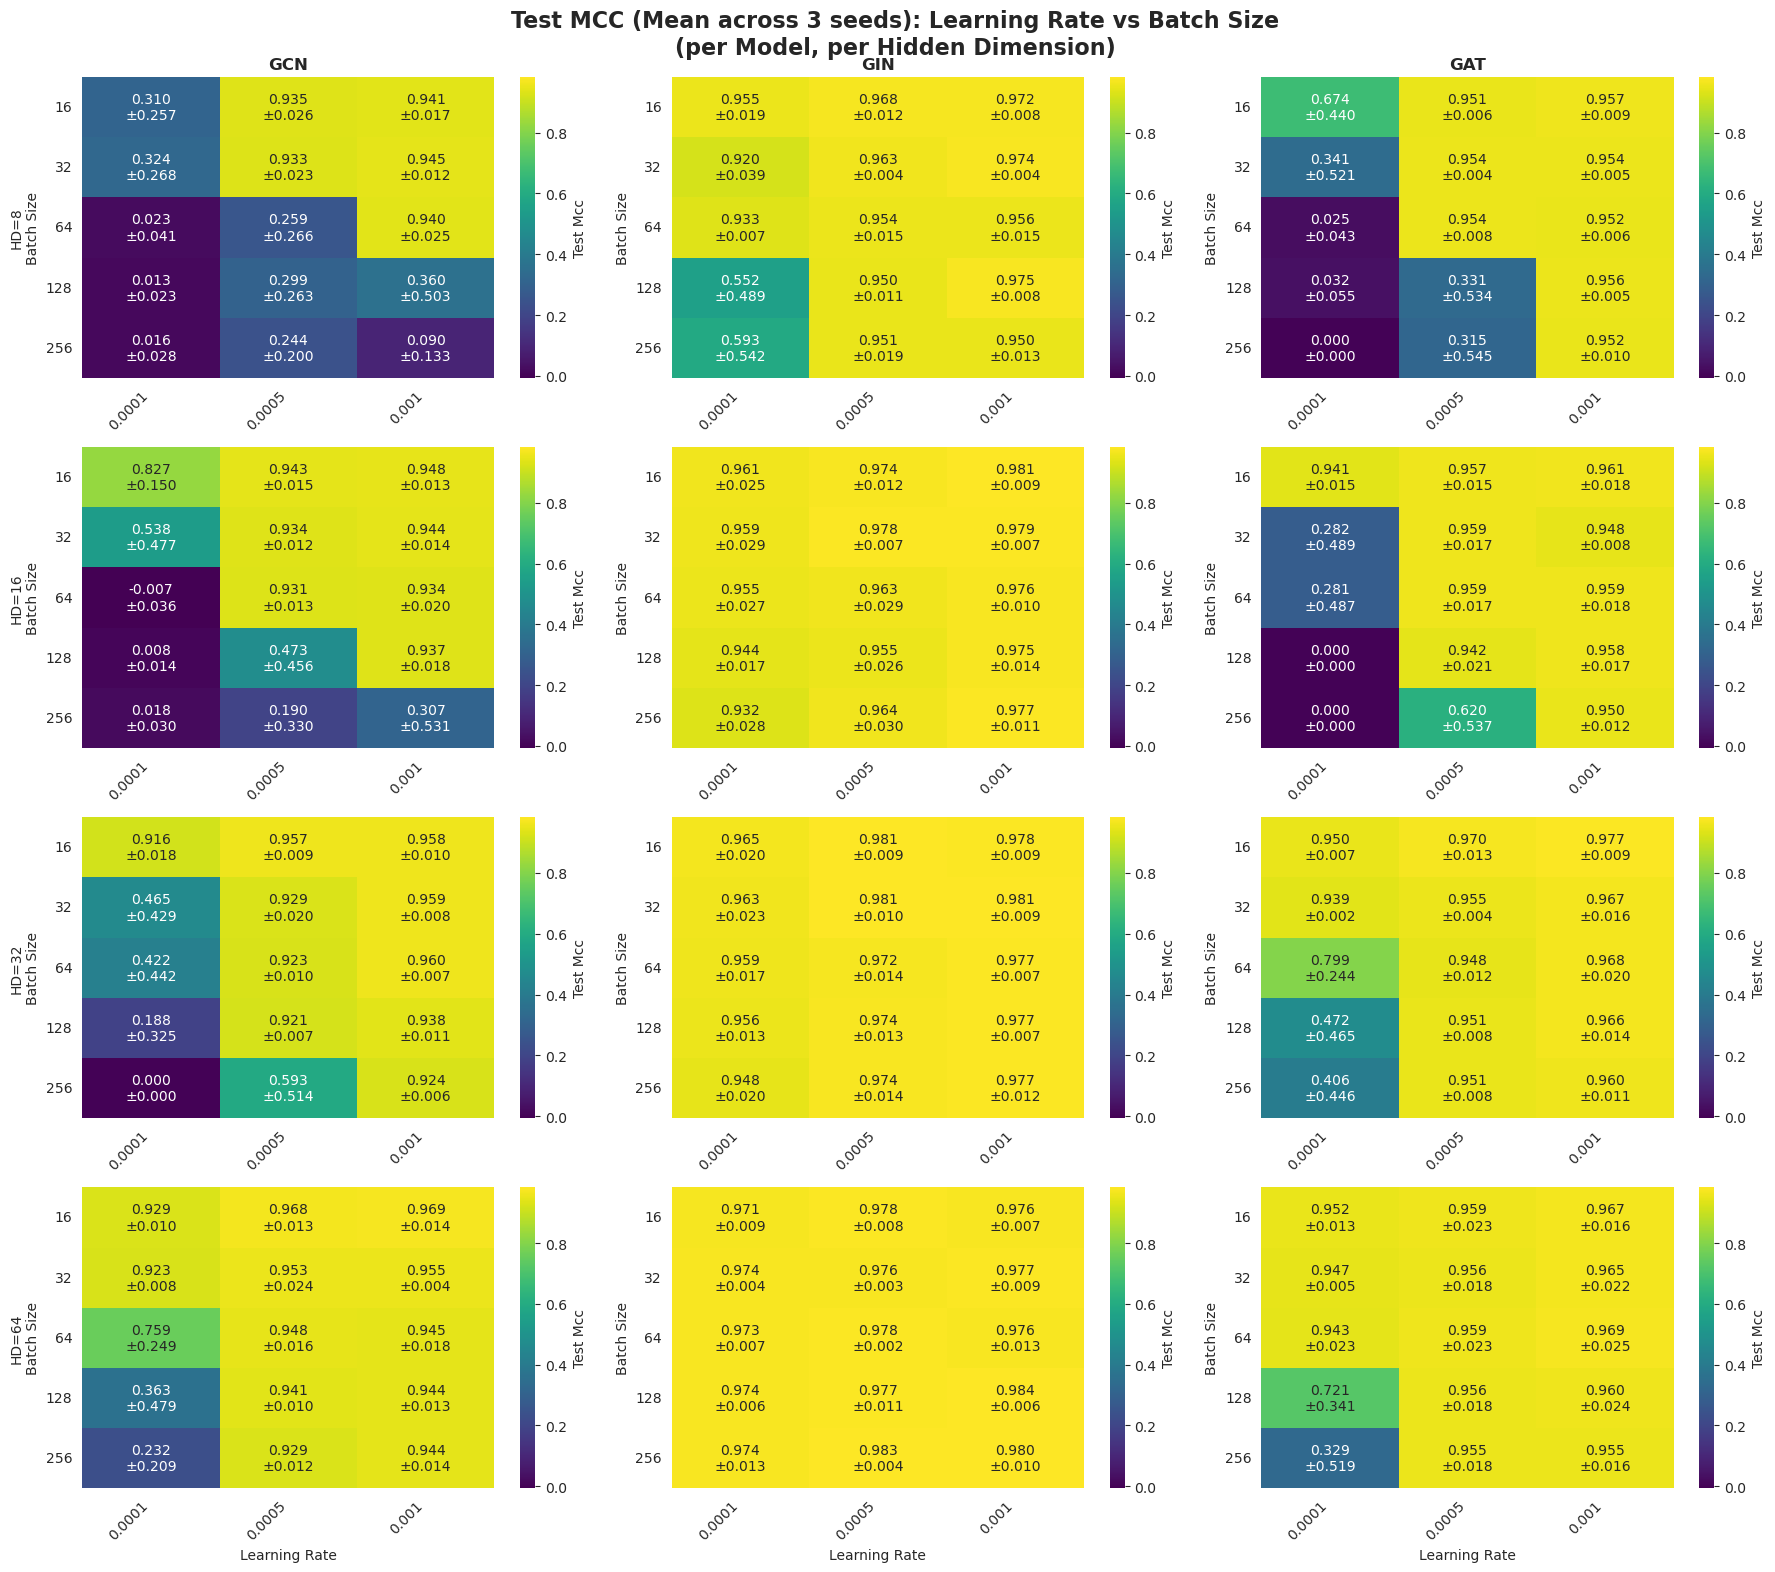

Visualization saved to: test_mcc_heatmaps.png

All visualizations use metrics averaged across 3 random seeds for robustness.


In [27]:
# VISUALIZATIONS
HIDDEN_DIM_GRID = [8, 16, 32, 64]
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
results_per_seed_df = pd.read_csv('hyperparameter_screening_results_per_seed.csv')
results_df = pd.read_csv('hyperparameter_screening_results.csv')
# Set style
sns.set_style("whitegrid")
def create_heatmap_grid(results_df, results_per_seed_df, metric_name, title, filename, cmap='viridis'):
    """Create and save heatmap grid for metric across all models and hidden dimensions, with std annotations."""
    fig, axes = plt.subplots(len(HIDDEN_DIM_GRID), 3, figsize=(18, 16))
    # Get global min/max for consistent color scale (based on mean)
    all_values = []
    for model in ['gcn', 'gin', 'gat']:
        all_values.extend(results_df[f'{model}_{metric_name}'].values)
    vmin_global, vmax_global = min(all_values), max(all_values)
    for hd_idx, hidden_dim in enumerate(HIDDEN_DIM_GRID):
        for model_idx, (model, model_name) in enumerate(zip(['gcn', 'gin', 'gat'], ['GCN', 'GIN', 'GAT'])):
            ax = axes[hd_idx, model_idx]
            # Get mean values
            subset = results_df[results_df['hidden_dim'] == hidden_dim]
            pivot_table = subset.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            # Get std values from per-seed results
            subset_per_seed = results_per_seed_df[results_per_seed_df['hidden_dim'] == hidden_dim]
            metric_cols_std = [col for col in subset_per_seed.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
            std_df = subset_per_seed.groupby(['batch_size', 'learning_rate'])[metric_cols_std].std().reset_index()
            pivot_std = std_df.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            # Create custom annotations with mean and std
            annot_data = []
            for i, bs in enumerate(pivot_table.index):
                row = []
                for lr in pivot_table.columns:
                    mean_val = pivot_table.loc[bs, lr]
                    std_val = pivot_std.loc[bs, lr] if (bs in pivot_std.index and lr in pivot_std.columns) else 0.0
                    row.append(f'{mean_val:.3f}\n±{std_val:.3f}')
                annot_data.append(row)
            sns.heatmap(pivot_table, annot=annot_data, fmt='', cmap=cmap, ax=ax,
                        cbar_kws={'label': metric_name.replace('_', ' ').title()}, 
                        vmin=vmin_global, vmax=vmax_global)
            if hd_idx == 0:
                ax.set_title(model_name, fontsize=12, fontweight='bold')
            if model_idx == 0:
                ax.set_ylabel(f'HD={hidden_dim}\nBatch Size', fontsize=10)
            else:
                ax.set_ylabel('Batch Size', fontsize=10)
            if hd_idx == len(HIDDEN_DIM_GRID) - 1:
                ax.set_xlabel('Learning Rate', fontsize=10)
            else:
                ax.set_xlabel('') 
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved to: {filename}")

# Create heatmaps
create_heatmap_grid(results_df, results_per_seed_df, 'test_mcc',
                   'Test MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'test_mcc_heatmaps.png', cmap='viridis')
print("\nAll visualizations use metrics averaged across 3 random seeds for robustness.")

In [28]:
#use optuna Bayes to find best hyperparameters based on test MCC
import optuna
def objective(trial, model_class):
    # Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', BATCH_SIZE_GRID)
    hidden_dim = trial.suggest_categorical('hidden_dim', HIDDEN_DIM_GRID)
    lr = trial.suggest_categorical('learning_rate', LEARNING_RATE_GRID)
    results_per_seed = []
    for seed in RANDOM_SEED_GRID:
        # Split data
        train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
        # Train model
        model_temp, thr_temp, test_accuracy, test_mcc = training_and_evaluation(
            model_class=model_class,
            train_loader=train_loader_temp, 
            val_loader=val_loader_temp, 
            test_loader=test_loader_temp, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
        results_per_seed.append({
            'batch_size': batch_size,
            'hidden_dim': hidden_dim,
            'learning_rate': lr,
            'random_seed': seed,
            'test_mcc': test_mcc
        })
    # Return average test MCC across seeds
    avg_mcc = np.mean([r['test_mcc'] for r in results_per_seed])
    print(f"{model_class.__name__} Trial with batch_size={batch_size}, hidden_dim={hidden_dim}, lr={lr} | Avg Test MCC across seeds: {avg_mcc:.4f}")
    return avg_mcc

study = optuna.create_study(direction='maximize')
for i in [GCN, GIN, GAT]:
    study.optimize(lambda trial: objective(trial, i), n_trials=20)

[I 2026-03-02 18:38:05,912] A new study created in memory with name: no-name-d6ae0a07-ec40-448a-b769-4844cc54da02



Training model: GCN
Epoch 05 | Train Loss: 0.2697 | Val MCC (opt thr): 0.9513
Epoch 10 | Train Loss: 0.2029 | Val MCC (opt thr): 0.9626
Epoch 15 | Train Loss: 0.1568 | Val MCC (opt thr): 0.9673
Epoch 20 | Train Loss: 0.1409 | Val MCC (opt thr): 0.9704
Early stopping at epoch 25 | Best MCC: 0.9704
Optimized threshold: 0.650
Test Accuracy: 0.9803
Test MCC: 0.9582

Training model: GCN
Epoch 05 | Train Loss: 0.2629 | Val MCC (opt thr): 0.9280
Epoch 10 | Train Loss: 0.1869 | Val MCC (opt thr): 0.9374
Early stopping at epoch 14 | Best MCC: 0.9374
Optimized threshold: 0.800
Test Accuracy: 0.9659
Test MCC: 0.9241

Training model: GCN
Epoch 05 | Train Loss: 0.2444 | Val MCC (opt thr): 0.9382
Epoch 10 | Train Loss: 0.1745 | Val MCC (opt thr): 0.9446
Epoch 15 | Train Loss: 0.1274 | Val MCC (opt thr): 0.9510
Epoch 20 | Train Loss: 0.1075 | Val MCC (opt thr): 0.9526
Epoch 25 | Train Loss: 0.0901 | Val MCC (opt thr): 0.9542
Epoch 30 | Train Loss: 0.0861 | Val MCC (opt thr): 0.9558
Early stopping at

[I 2026-03-02 18:39:23,163] Trial 0 finished with value: 0.9449237845820971 and parameters: {'batch_size': 64, 'hidden_dim': 64, 'learning_rate': 0.001}. Best is trial 0 with value: 0.9449237845820971.


Optimized threshold: 0.850
Test Accuracy: 0.9772
Test MCC: 0.9525
GCN Trial with batch_size=64, hidden_dim=64, lr=0.001 | Avg Test MCC across seeds: 0.9449

Training model: GCN
Epoch 05 | Train Loss: 0.3178 | Val MCC (opt thr): 0.9340
Epoch 10 | Train Loss: 0.2405 | Val MCC (opt thr): 0.9481
Epoch 15 | Train Loss: 0.2046 | Val MCC (opt thr): 0.9548
Epoch 20 | Train Loss: 0.1734 | Val MCC (opt thr): 0.9610
Epoch 25 | Train Loss: 0.1611 | Val MCC (opt thr): 0.9639
Early stopping at epoch 26 | Best MCC: 0.9641
Optimized threshold: 0.800
Test Accuracy: 0.9795
Test MCC: 0.9566

Training model: GCN
Epoch 05 | Train Loss: 0.2807 | Val MCC (opt thr): 0.9265
Epoch 10 | Train Loss: 0.2017 | Val MCC (opt thr): 0.9343
Epoch 15 | Train Loss: 0.1628 | Val MCC (opt thr): 0.9455
Epoch 20 | Train Loss: 0.1269 | Val MCC (opt thr): 0.9532
Epoch 25 | Train Loss: 0.1116 | Val MCC (opt thr): 0.9548
Epoch 30 | Train Loss: 0.0946 | Val MCC (opt thr): 0.9593
Epoch 35 | Train Loss: 0.0842 | Val MCC (opt thr): 0

[I 2026-03-02 18:42:58,247] Trial 1 finished with value: 0.9546949507201612 and parameters: {'batch_size': 16, 'hidden_dim': 32, 'learning_rate': 0.0005}. Best is trial 1 with value: 0.9546949507201612.


...

Test Accuracy: 0.9750
Test MCC: 0.9478
GAT Trial with batch_size=256, hidden_dim=32, lr=0.001 | Avg Test MCC across seeds: 0.9610

Training model: GAT
Epoch 05 | Train Loss: 0.2348 | Val MCC (opt thr): 0.9544
Epoch 10 | Train Loss: 0.1324 | Val MCC (opt thr): 0.9702
Epoch 15 | Train Loss: 0.0902 | Val MCC (opt thr): 0.9875
Epoch 20 | Train Loss: 0.0544 | Val MCC (opt thr): 0.9937
Epoch 25 | Train Loss: 0.0462 | Val MCC (opt thr): 0.9937
Epoch 30 | Train Loss: 0.0424 | Val MCC (opt thr): 0.9953
Early stopping at epoch 31 | Best MCC: 0.9953
Optimized threshold: 0.200
Test Accuracy: 0.9962
Test MCC: 0.9920

Training model: GAT
Epoch 05 | Train Loss: 0.2123 | Val MCC (opt thr): 0.9374
Epoch 10 | Train Loss: 0.1136 | Val MCC (opt thr): 0.9518
Early stopping at epoch 13 | Best MCC: 0.9532
Optimized threshold: 0.900
Test Accuracy: 0.9777
Test MCC: 0.9502

Training model: GAT
Epoch 05 | Train Loss: 0.2122 | Val MCC (opt thr): 0.9446
Epoch 10 | Train Loss: 0.1826 | Val MCC (opt thr): 0.9494
Epo

[I 2026-03-02 20:03:38,561] Trial 58 finished with value: 0.9696378534751169 and parameters: {'batch_size': 128, 'hidden_dim': 64, 'learning_rate': 0.001}. Best is trial 21 with value: 0.9799788562866896.


Optimized threshold: 0.400
Test Accuracy: 0.9841
Test MCC: 0.9668
GAT Trial with batch_size=128, hidden_dim=64, lr=0.001 | Avg Test MCC across seeds: 0.9696

Training model: GAT
Epoch 05 | Train Loss: 0.2144 | Val MCC (opt thr): 0.9593
Epoch 10 | Train Loss: 0.1506 | Val MCC (opt thr): 0.9720
Epoch 15 | Train Loss: 0.1140 | Val MCC (opt thr): 0.9812
Epoch 20 | Train Loss: 0.0706 | Val MCC (opt thr): 0.9874
Epoch 25 | Train Loss: 0.0596 | Val MCC (opt thr): 0.9906
Early stopping at epoch 28 | Best MCC: 0.9906
Optimized threshold: 0.300
Test Accuracy: 0.9916
Test MCC: 0.9823

Training model: GAT
Epoch 05 | Train Loss: 0.1871 | Val MCC (opt thr): 0.9501
Epoch 10 | Train Loss: 0.1200 | Val MCC (opt thr): 0.9518
Early stopping at epoch 13 | Best MCC: 0.9534
Optimized threshold: 0.950
Test Accuracy: 0.9812
Test MCC: 0.9581

Training model: GAT
Epoch 05 | Train Loss: 0.1846 | Val MCC (opt thr): 0.9510
Epoch 10 | Train Loss: 0.1083 | Val MCC (opt thr): 0.9574
Epoch 15 | Train Loss: 0.0888 | Va

[I 2026-03-02 20:07:14,999] Trial 59 finished with value: 0.9711357704878586 and parameters: {'batch_size': 16, 'hidden_dim': 32, 'learning_rate': 0.0005}. Best is trial 21 with value: 0.9799788562866896.


Test Accuracy: 0.9871
Test MCC: 0.9730
GAT Trial with batch_size=16, hidden_dim=32, lr=0.0005 | Avg Test MCC across seeds: 0.9711


In [ ]:
#[I 2026-03-02 19:11:01,656] Trial 21 finished with value: 0.9799788562866896 and parameters: {'batch_size': 128, 'hidden_dim': 32, 'learning_rate': 0.001}. Best is trial 21 with value: 0.9799788562866896
#use GIN with batch_size=128, hidden_dim=32, learning_rate=0.001 to train final model and evaluate on gen sets
BATCH_SIZE = 128
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42
final_model, thr, test_acc, test_mcc = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
print(f"Final Model (GIN) Test Accuracy: {test_acc:.4f}, Test MCC: {test_acc:.4f}, Confidence Threshold {thr:.4f}")
torch.save(final_model.state_dict(), f'final_gin_model_seed_{RANDOM_SEED}.pth')


Training model: GIN
Epoch 05 | Train Loss: 0.1739 | Val MCC (opt thr): 0.9859
Epoch 10 | Train Loss: 0.1002 | Val MCC (opt thr): 0.9906
Epoch 15 | Train Loss: 0.0846 | Val MCC (opt thr): 0.9921
Epoch 20 | Train Loss: 0.0702 | Val MCC (opt thr): 0.9906
Early stopping at epoch 24 | Best MCC: 0.9922
Optimized threshold: 0.800
Test Accuracy: 0.9947
Test MCC: 0.9887
Final Model (GIN) Test Accuracy: 0.9947, Test MCC: 0.9947, Confidence Threshold 0.8000


In [31]:
BATCH_SIZE = 128
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 21
final_model, thr, test_acc, test_mcc = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
print(f"Final Model (GIN) Test Accuracy: {test_acc:.4f}, Test MCC: {test_acc:.4f}, Confidence Threshold {thr:.4f}")
torch.save(final_model.state_dict(), f'final_gin_model_seed_{RANDOM_SEED}.pth')


Training model: GIN
Epoch 05 | Train Loss: 0.2069 | Val MCC (opt thr): 0.9734
Epoch 10 | Train Loss: 0.1105 | Val MCC (opt thr): 0.9844
Epoch 15 | Train Loss: 0.1002 | Val MCC (opt thr): 0.9844
Epoch 20 | Train Loss: 0.0793 | Val MCC (opt thr): 0.9829
Early stopping at epoch 21 | Best MCC: 0.9875
Optimized threshold: 0.300
Test Accuracy: 0.9903
Test MCC: 0.9783
Final Model (GIN) Test Accuracy: 0.9903, Test MCC: 0.9903, Confidence Threshold 0.3000


In [32]:
BATCH_SIZE = 128
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 0
final_model, thr, test_acc, test_mcc = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
print(f"Final Model (GIN) Test Accuracy: {test_acc:.4f}, Test MCC: {test_acc:.4f}, Confidence Threshold {thr:.4f}")
torch.save(final_model.state_dict(), f'final_gin_model_seed_{RANDOM_SEED}.pth')


Training model: GIN
Epoch 05 | Train Loss: 0.2939 | Val MCC (opt thr): 0.9636
Epoch 10 | Train Loss: 0.1444 | Val MCC (opt thr): 0.9716
Epoch 15 | Train Loss: 0.0997 | Val MCC (opt thr): 0.9827
Epoch 20 | Train Loss: 0.0661 | Val MCC (opt thr): 0.9874
Early stopping at epoch 23 | Best MCC: 0.9874
Optimized threshold: 0.650
Test Accuracy: 0.9863
Test MCC: 0.9714
Final Model (GIN) Test Accuracy: 0.9863, Test MCC: 0.9863, Confidence Threshold 0.6500


In [ ]:
'''
gen_set_1_1 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach1.csv", index_col=False)["SMILES"].tolist()
gen_set_1_2 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach2.csv", index_col=False)["SMILES"].tolist()
gen_set_1 = gen_set_1_1 + gen_set_1_2
#remove duplicates
gen_set_1 = list(set(gen_set_1))
print(f'Number of unique molecules in gen_set_1: {len(gen_set_1)}')
#
gen_set_2 = pd.read_csv("../genAI/reinvent4_test/cleaned_fresh_imide_molecules_top200_QED.csv", index_col=False)["SMILES"].tolist()
gen_set_2 = list(set(gen_set_2))
print(f'Number of unique molecules in gen_set_2: {len(gen_set_2)}')
#
gen_set_combined = list(set(gen_set_1 + gen_set_2)) 
print(f'Number of unique molecules in gen_set_combined: {len(gen_set_combined)}')
#
cov_dock_set = pd.read_csv("../covalent_docking_VS/covalent_docking_unique_2D_precursors_QED_filtered_above_049.csv", index_col=False)["SMILES"].tolist()
cov_dock_set = list(set(cov_dock_set))
print(f'Number of unique molecules in cov_dock_set: {len(cov_dock_set)}')
#
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gcn_model,[(gen_set_combined, 0), (cov_dock_set, 1),], 0.6, BATCH_SIZE, device)
#
BATCH_SIZE = 32
HIDDEN_DIM = 32
LEARNING_RATE = 0.005 
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gat_model, [(gen_set_combined, 0), (cov_dock_set, 1),], 0.3, BATCH_SIZE, device)
#
BATCH_SIZE = 16
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gin_model, [(gen_set_combined, 0), (cov_dock_set, 1),], 0.65, BATCH_SIZE, device)
'''

In [ ]:
'''
# HYPERPARAMETER SCREENING

import itertools
import math
from datetime import datetime

# Define hyperparameter grid
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
HIDDEN_DIM_GRID = [8, 16, 32, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
RANDOM_SEED_GRID = [42, 21, 0]

# Storage for results - now includes seed information
results_per_seed = []

# Total combinations
total_combinations = len(BATCH_SIZE_GRID) * len(HIDDEN_DIM_GRID) * len(LEARNING_RATE_GRID) * len(RANDOM_SEED_GRID)
print(f"Starting hyperparameter screening with {total_combinations} combinations...")
print(f"(Testing {len(BATCH_SIZE_GRID)} batch sizes × {len(HIDDEN_DIM_GRID)} hidden dims × {len(LEARNING_RATE_GRID)} learning rates × {len(RANDOM_SEED_GRID)} seeds)")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)

combination_counter = 0

for batch_size, hidden_dim, lr, seed in itertools.product(BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID):
    combination_counter += 1
    print(f"\n[{combination_counter}/{total_combinations}] Testing: BATCH_SIZE={batch_size}, HIDDEN_DIM={hidden_dim}, LR={lr}, SEED={seed}")
    
    train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
    
    # GCN
    model_temp, thr_temp, gcn_test_accuracy, gcn_test_mcc = training_and_evaluation(
        model_class=GCN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gcn_gen_all_acc, gcn_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GIN
    model_temp, thr_temp, gin_test_accuracy, gin_test_mcc = training_and_evaluation(
        model_class=GIN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gin_gen_all_acc, gin_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GAT
    model_temp, thr_temp, gat_test_accuracy, gat_test_mcc = training_and_evaluation(
        model_class=GAT,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gat_gen_all_acc, gat_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # Store results with seed information
    result = {
        'batch_size': batch_size,
        'hidden_dim': hidden_dim,
        'learning_rate': lr,
        'random_seed': seed,
        # GCN
        'gcn_test_acc': gcn_test_accuracy,
        'gcn_test_mcc': gcn_test_mcc,
        'gcn_gen_all_acc': gcn_gen_all_acc,
        'gcn_gen_all_mcc': gcn_gen_all_mcc,
        # GIN
        'gin_test_acc': gin_test_accuracy,
        'gin_test_mcc': gin_test_mcc,
        'gin_gen_all_acc': gin_gen_all_acc,
        'gin_gen_all_mcc': gin_gen_all_mcc,
        # GAT
        'gat_test_acc': gat_test_accuracy,
        'gat_test_mcc': gat_test_mcc,
        'gat_gen_all_acc': gat_gen_all_acc,
        'gat_gen_all_mcc': gat_gen_all_mcc,
    }
    results_per_seed.append(result)

print("\n" + "=" * 100)
print(f"Screening completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total combinations tested: {len(results_per_seed)}")
print(f"Unique hyperparameter combinations: {len(results_per_seed) // len(RANDOM_SEED_GRID)}")
'''


In [ ]:
'''
# Convert results to DataFrame
results_per_seed_df = pd.DataFrame(results_per_seed)
results_per_seed_df.to_csv('hyperparameter_screening_results_per_seed.csv', index=False)
# Aggregate results by taking mean across random seeds
metric_cols = [col for col in results_per_seed_df.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
results_df = results_per_seed_df.groupby(['batch_size', 'hidden_dim', 'learning_rate'])[metric_cols].mean().reset_index()
results_df.to_csv('hyperparameter_screening_results.csv', index=False)
'''

In [ ]:
'''
# ANALYSIS - Summary statistics

def print_stats(label, values):
    """Helper to print mean, std, min, max for a metric."""
    return f"{label}: {values.mean():.4f} ± {values.std():.4f} (min: {values.min():.4f}, max: {values.max():.4f})"

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS (averaged across {len(RANDOM_SEED_GRID)} seeds per hyperparameter combination)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    print(f"\n{model.upper()}:")
    print(f"  {print_stats('Test MCC', results_df[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Combined Gen MCC', results_df[f'{model}_gen_all_mcc'])}")

# Best hyperparameters analysis
print(f"\n{'='*100}")
print(f"BEST HYPERPARAMETERS for Combined Gen MCC (across {len(RANDOM_SEED_GRID)} seeds)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    best_idx = results_df[f'{model}_gen_all_mcc'].idxmax()
    best_row = results_df.iloc[best_idx]
    
    # Filter per-seed results for best hyperparameters
    best_per_seed = results_per_seed_df[
        (results_per_seed_df['batch_size'] == best_row['batch_size']) &
        (results_per_seed_df['hidden_dim'] == best_row['hidden_dim']) &
        (results_per_seed_df['learning_rate'] == best_row['learning_rate'])
    ]
    
    print(f"\nBest {model.upper()}: BS={int(best_row['batch_size'])}, HD={int(best_row['hidden_dim'])}, LR={best_row['learning_rate']}")
    print(f"  {print_stats('Test MCC', best_per_seed[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Gen MCC', best_per_seed[f'{model}_gen_all_mcc'])}")
'''

In [ ]:
'''
# VISUALIZATIONS

HIDDEN_DIM_GRID = [8, 16, 32, 64]
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
results_per_seed_df = pd.read_csv('hyperparameter_screening_results_per_seed.csv')
results_df = pd.read_csv('hyperparameter_screening_results.csv')

# Set style
sns.set_style("whitegrid")

def create_heatmap_grid(results_df, results_per_seed_df, metric_name, title, filename, cmap='viridis'):
    """Create and save heatmap grid for metric across all models and hidden dimensions, with std annotations."""
    fig, axes = plt.subplots(len(HIDDEN_DIM_GRID), 3, figsize=(18, 16))
    
    # Get global min/max for consistent color scale (based on mean)
    all_values = []
    for model in ['gcn', 'gin', 'gat']:
        all_values.extend(results_df[f'{model}_{metric_name}'].values)
    vmin_global, vmax_global = min(all_values), max(all_values)
    
    for hd_idx, hidden_dim in enumerate(HIDDEN_DIM_GRID):
        for model_idx, (model, model_name) in enumerate(zip(['gcn', 'gin', 'gat'], ['GCN', 'GIN', 'GAT'])):
            ax = axes[hd_idx, model_idx]
            
            # Get mean values
            subset = results_df[results_df['hidden_dim'] == hidden_dim]
            pivot_table = subset.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Get std values from per-seed results
            subset_per_seed = results_per_seed_df[results_per_seed_df['hidden_dim'] == hidden_dim]
            metric_cols_std = [col for col in subset_per_seed.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
            std_df = subset_per_seed.groupby(['batch_size', 'learning_rate'])[metric_cols_std].std().reset_index()
            pivot_std = std_df.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Create custom annotations with mean and std
            annot_data = []
            for i, bs in enumerate(pivot_table.index):
                row = []
                for lr in pivot_table.columns:
                    mean_val = pivot_table.loc[bs, lr]
                    std_val = pivot_std.loc[bs, lr] if (bs in pivot_std.index and lr in pivot_std.columns) else 0.0
                    row.append(f'{mean_val:.3f}\n±{std_val:.3f}')
                annot_data.append(row)
            
            sns.heatmap(pivot_table, annot=annot_data, fmt='', cmap=cmap, ax=ax,
                        cbar_kws={'label': metric_name.replace('_', ' ').title()}, 
                        vmin=vmin_global, vmax=vmax_global)
            
            if hd_idx == 0:
                ax.set_title(model_name, fontsize=12, fontweight='bold')
            if model_idx == 0:
                ax.set_ylabel(f'HD={hidden_dim}\nBatch Size', fontsize=10)
            else:
                ax.set_ylabel('Batch Size', fontsize=10)
            if hd_idx == len(HIDDEN_DIM_GRID) - 1:
                ax.set_xlabel('Learning Rate', fontsize=10)
            else:
                ax.set_xlabel('')
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved to: {filename}")

# Create heatmaps
create_heatmap_grid(results_df, results_per_seed_df, 'gen_all_mcc', 
                   'Combined Gen MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'combined_gen_mcc_heatmaps.png', cmap='coolwarm')

create_heatmap_grid(results_df, results_per_seed_df, 'test_mcc',
                   'Test MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'test_mcc_heatmaps.png', cmap='viridis')

print("\nAll visualizations use metrics averaged across 3 random seeds for robustness.")
'''

In [ ]:
'''
#use optuna Bayes to find best hyperparameters based on test MCC
import optuna

def objective(trial, model_class):
    # Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', BATCH_SIZE_GRID)
    hidden_dim = trial.suggest_categorical('hidden_dim', HIDDEN_DIM_GRID)
    lr = trial.suggest_categorical('learning_rate', LEARNING_RATE_GRID)
    
    results_per_seed = []

    for seed in RANDOM_SEED_GRID:
        # Split data
        train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
        
        # Train model
        model_temp, thr_temp, test_accuracy, test_mcc = training_and_evaluation(
            model_class=model_class,
            train_loader=train_loader_temp, 
            val_loader=val_loader_temp, 
            test_loader=test_loader_temp, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
        results_per_seed.append({
            'batch_size': batch_size,
            'hidden_dim': hidden_dim,
            'learning_rate': lr,
            'random_seed': seed,
            'test_mcc': test_mcc
        })

    # Return average test MCC across seeds (or you could choose best seed)
    avg_mcc = np.mean([r['test_mcc'] for r in results_per_seed])
    print(f"{model_class.__name__} Trial with batch_size={batch_size}, hidden_dim={hidden_dim}, lr={lr} | Avg Test MCC across seeds: {avg_mcc:.4f}")
    return avg_mcc

study = optuna.create_study(direction='maximize')
for i in [GCN, GIN, GAT]:
    study.optimize(lambda trial: objective(trial, i), n_trials=20)
'''

In [ ]:
'''
#[I 2026-02-05 12:01:48,025] Trial 38 finished with value: 0.9785395742543255 and parameters: {'batch_size': 256, 'hidden_dim': 16, 'learning_rate': 0.001}. Best is trial 38 with value: 0.9785395742543255.
#use GIN with batch_size=256, hidden_dim=16, learning_rate=0.001 to train final model and evaluate on gen sets
BATCH_SIZE = 256
HIDDEN_DIM = 16
LEARNING_RATE = 0.001
RANDOM_SEED = 42
final_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
final_gen_all_acc, final_gen_all_mcc = predict_combined_accuracy_and_mcc(
    final_model,
    [
        (gen_set_combined, 0),
        (cov_dock_set, 1),
    ],
    thr,
    BATCH_SIZE,
    device,
)
print(f"Final Model (GIN) Combined Gen Accuracy: {final_gen_all_acc:.4f}, Combined Gen MCC: {final_gen_all_mcc:.4f}")
'''